#Sleep Health Data Analysis Pipeline
### A Reproducible Pipeline for Uncovering Patterns Between Lifestyle Factors and Health Indicators

**Author:** Damilola Olatunji  
**Dataset:** Sleep Health and Lifestyle Dataset (374 records)  
**Objective:** To identify meaningful relationships between physical activity, stress, occupation, BMI, blood pressure, and sleep outcomes.

---

In [43]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore') #Removing warning messages to keep the notebook clean

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 156
np.random.seed(RANDOM_STATE)

#Aesthetic Configuration
#Changing chart style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
#Creating color palette with hex codes
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#F44336', '#8BC34A']

print(f'Random state set to: {RANDOM_STATE}')
print('Libraries successfully loaded!')

Random state set to: 156
Libraries successfully loaded!


##Section A: Data Readiness and Feature Logic

In [27]:
#Loading dataset and inspecting column names, missing data and data types
sleep_data = pd.read_csv('/content/drive/MyDrive/Datasets/Sleep_health_and_lifestyle_dataset.csv') #this reads the csv file
print(f'Shape of dataset: {sleep_data.shape}') #Show the numbers of rows and columns of the dataset
print(f'\nColumns of dataset: {sleep_data.columns.tolist()}') #Shows a list of columns in the dataset
print(f"\nData Types:")
print(sleep_data.dtypes) #Checking for the data type of values in each columns.
print(f'\n Checking for missing values: \n{sleep_data.isnull().sum()}') #Checking for the number of missing value

# I exclude Person ID from duplicate detection because each row represents
# a distinct individual even if their lifestyle profiles are identical.
print('\n Duplicates:')
dup_count = sleep_data.duplicated(subset=sleep_data.columns.drop('Person ID')).sum()
print(f'Duplicate rows (excluding Person ID): {dup_count}')
print('NOTE: Many rows share identical feature values — retained as distinct individuals.')

sleep_data.head(10)

Shape of dataset: (374, 13)

Columns of dataset: ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']

Data Types:
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

 Checking for missing values: 
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level 

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [28]:
#Check unique values to inspect duplicates in Occupation, Gender, BMI Category and sleep disorder columns
print (f'\n Unique value of occupation: {sleep_data['Occupation'].unique()}')
print (f'\n Unique value of Gender: {sleep_data['Gender'].unique()}')
print (f'\n Unique value of BMI Category: {sleep_data['BMI Category'].unique()}')
print (f'\n Unique value of Sleep Disorder: {sleep_data['Sleep Disorder'].unique()}')


 Unique value of occupation: ['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']

 Unique value of Gender: ['Male' 'Female']

 Unique value of BMI Category: ['Overweight' 'Normal' 'Obese' 'Normal Weight']

 Unique value of Sleep Disorder: [nan 'Sleep Apnea' 'Insomnia']


In [29]:
#Dealing with missing values in sleep disorder column by replacing 'nan' to 'None'
#Rationale: 'None' indicates no reported sleep disorder
sleep_data['Sleep Disorder'] = sleep_data['Sleep Disorder'].fillna('None')

#Dealing with BMI Category: Harmonizing 'Normal' and 'Normal Weight'
#Rationale: 'Normal' and 'Normal Weight' are the same values.
sleep_data['BMI Category'] = sleep_data['BMI Category'].replace('Normal Weight', 'Normal')

print(sleep_data ['BMI Category'].unique())
print(sleep_data ['Sleep Disorder'].unique())

sleep_data.head(10)


['Overweight' 'Normal' 'Obese']
['None' 'Sleep Apnea' 'Insomnia']


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None


In [30]:
#Splitting Blood pressure to create new columns for systolic and diastolic blood pressure
sleep_data[['Systolic BP', 'Diastolic BP']] = sleep_data['Blood Pressure'].str.split('/', expand=True).astype(int)
sleep_data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [31]:
#Summary of descriptive statistic (excluding 'person ID' column because it is not relevant)
sleep_data.drop(columns=['Person ID']).describe().round(2)

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic BP,Diastolic BP
count,374.00,374.00,374.00,374.00,374.00,374.00,374.00,374.00,374.00
mean,42.18,7.13,7.31,59.17,5.39,70.17,6816.84,128.55,84.65
std,8.67,0.80,1.20,20.83,1.77,4.14,1617.92,7.75,6.16
min,27.00,5.80,4.00,30.00,3.00,65.00,3000.00,115.00,75.00
25%,35.25,6.40,6.00,45.00,4.00,68.00,5600.00,125.00,80.00
50%,43.00,7.20,7.00,60.00,5.00,70.00,7000.00,130.00,85.00
75%,50.00,7.80,8.00,75.00,7.00,72.00,8000.00,135.00,90.00
max,59.00,8.50,9.00,90.00,8.00,86.00,10000.00,142.00,95.00


## Creating New Categorical Groups

In [32]:
# FEATURE 1: Sleep Quality Grouping
# Rationale: Sleep quality is scored 1–10.
# Categories: Poor (≤5), Moderate (6–7), Good (≥8).
#Creating custom function to convert numerical values to categorical values.
def classify_sleep_quality(i):
    if i <= 5: return 'Poor (≤5)'
    elif i <= 7: return 'Moderate (6–7)'
    else:  return 'Good (≥8)'

sleep_data['Sleep Quality Group'] = sleep_data['Quality of Sleep'].apply(classify_sleep_quality) #Creating new column and applying classify_sleep_quality to all values.
order_s = ['Poor (≤5)', 'Moderate (6–7)', 'Good (≥8)'] #Setting sleep quality order from poor to good.
sleep_data['Sleep Quality Group'] = pd.Categorical(sleep_data['Sleep Quality Group'], categories=order_s, ordered=True)#Creating new column and applying pandas method to convert values to ordinal values.

# FEATURE 2: Sleep Duration Group
# Rationale: Sleep duration ranges from minimum of 7 hours and maximum of 9 hours.
# Categories: <7 hours = insufficient; 7–9 hours = adequate; >9 hours = excessive.
#Creating custom function to convert numerical value to categorical value
def classify_sleep_duration(j):
    if j < 7: return 'Insufficient (<7h)'
    elif j <= 9: return 'Adequate (7–9h)'
    else:        return 'Excessive (>9h)'

sleep_data['Sleep Duration Group'] = sleep_data['Sleep Duration'].apply(classify_sleep_duration) #Creating new column and applying custom function to all values in column
sd_order = ['Insufficient (<7h)', 'Adequate (7–9h)', 'Excessive (>9h)'] #setting sleep duration order from insufficient to excessive
sleep_data['Sleep Duration Group'] = pd.Categorical(sleep_data['Sleep Duration Group'], categories=sd_order, ordered=True) #pandas method converts to ordinal value

# FEATURE 3: Physical Activity Group
# Rationale: WHO recommends ≥150 min/week moderate activity (~21 min/day).
#   We use units in dataset as activity minutes per day proxy:
#   Low (<40), Moderate (40–69), High (≥70)
def classify_activity(k):
    if k < 40:   return 'Low (<40)'
    elif k < 70: return 'Moderate (40–69)'
    else:        return 'High (≥70)'

sleep_data['Activity Group'] = sleep_data['Physical Activity Level'].apply(classify_activity) #Creating new column and applying custom function to all values in colum
phy_order = ['Low (<40)', 'Moderate (40–69)', 'High (≥70)'] #setting activity order from low to high
sleep_data['Activity Group'] = pd.Categorical(sleep_data['Activity Group'], categories=phy_order, ordered=True) #pandas method converts to ordinal value

# FEATURE 4: Blood Pressure Category
# Rationale: American Heart Association (AHA) guidelines define:
#   Normal: <120/80 | Elevated: 120–129/<80 | Stage 1 HTN: 130–139/80–89 | Stage 2 HTN: ≥140/≥90

def classify_bp(row):
    a, b = row['Systolic BP'], row['Diastolic BP']
    if a >= 140 or b >= 90:    return 'Stage 2 HTN (≥140/90)'
    elif a >= 130 or b >= 80:  return 'Stage 1 HTN (130–139/80–89)'
    elif a >= 120:             return 'Elevated (120–129/<80)'
    else:                      return 'Normal (<120/80)'

sleep_data['BP Category Long'] = sleep_data.apply(classify_bp, axis=1) #Creating new column and applying custom function to all values row by row.
bp_order = ['Normal (<120/80)', 'Elevated (120–129/<80)', 'Stage 1 HTN (130–139/80–89)', 'Stage 2 HTN (≥140/90)']
sleep_data['BP Category Long'] = pd.Categorical(sleep_data['BP Category Long'], categories=bp_order, ordered=True)

# FEATURE 5: Step Count Grouping
# Rationale: CDC identifies 8,000+ daily steps with significantly lower mortality.
# Categories : Low (<5,000), Moderate (5,000–7,999), Active (≥8,000)

def classify_steps(s):
    if s < 5000:  return 'Low (<5k)'
    elif s < 8000: return 'Moderate (5k–7.9k)'
    else:          return 'Active (≥8k)'

sleep_data['Step Group'] = sleep_data['Daily Steps'].apply(classify_steps)
step_order = ['Low (<5k)', 'Moderate (5k–7.9k)', 'Active (≥8k)']
sleep_data['Step Group'] = pd.Categorical(sleep_data['Step Group'], categories=step_order, ordered=True)

#FEATURE 6: Blood Pressure Category
# Rationale: American Heart Association (AHA) guidelines define:
#   Normal: <120/80 | Elevated: 120–129/<80 | Stage 1 HTN: 130–139/80–89 | Stage 2 HTN: ≥140/≥90
def classify_bp(row):
    a, b = row['Systolic BP'], row['Diastolic BP']
    if a >= 140 or b >= 90:    return 'Stage 2 HTN (≥140/90)'
    elif a >= 130 or b >= 80:  return 'Stage 1 HTN (130–139/80–89)'
    elif a >= 120:             return 'Elevated (120–129/<80)'
    else:                      return 'Normal (<120/80)'

sleep_data['BP Category Short'] = sleep_data.apply(classify_bp, axis=1)
bp_order = ['Normal (<120/80)', 'Elevated (120–129/<80)', 'Stage 1 HTN (130–139/80–89)', 'Stage 2 HTN (≥140/90)']
bporder_split = [item.split(' (')[0] for item in bp_order] #Separating numbers in paranthesis from the value labels.
sleep_data['BP Category Short'] = pd.Categorical(sleep_data['BP Category Short'], categories=bp_order, ordered=True)
sleep_data['BP Category Short'] = sleep_data['BP Category Short'].cat.rename_categories(bporder_split)#Applying method to rename value labels.

#Summarizing all newly created columns
print("New columns Summary:")
for col in ['Sleep Quality Group', 'Sleep Duration Group', 'Activity Group', 'BP Category Long', 'BP Category Short', 'Step Group']:
    print(f"  \n{col}: \n{sleep_data[col].value_counts().to_dict()}")


New columns Summary:
  
Sleep Quality Group: 
{'Moderate (6–7)': 182, 'Good (≥8)': 180, 'Poor (≤5)': 12}
  
Sleep Duration Group: 
{'Adequate (7–9h)': 219, 'Insufficient (<7h)': 155, 'Excessive (>9h)': 0}
  
Activity Group: 
{'Moderate (40–69)': 159, 'High (≥70)': 141, 'Low (<40)': 74}
  
BP Category Long: 
{'Stage 1 HTN (130–139/80–89)': 232, 'Stage 2 HTN (≥140/90)': 100, 'Normal (<120/80)': 41, 'Elevated (120–129/<80)': 1}
  
BP Category Short: 
{'Stage 1 HTN': 232, 'Stage 2 HTN': 100, 'Normal': 41, 'Elevated': 1}
  
Step Group: 
{'Moderate (5k–7.9k)': 218, 'Active (≥8k)': 137, 'Low (<5k)': 19}


In [33]:
# Final clean dataset summary
print("Final Dataset Summary")
print(f"\nTotal records : {len(sleep_data)}")
print(f"\nAge range     : {sleep_data['Age'].min()}–{sleep_data['Age'].max()} years")
print(f"\nGender split  : {sleep_data['Gender'].value_counts().to_dict()}")
print(f"\nOccupations   : {sleep_data['Occupation'].nunique()} occupation")
print(f"\nSleep Disorder: {sleep_data['Sleep Disorder'].value_counts().to_dict()}")
sleep_data.head()

Final Dataset Summary

Total records : 374

Age range     : 27–59 years

Gender split  : {'Male': 189, 'Female': 185}

Occupations   : 11 occupation

Sleep Disorder: {'None': 219, 'Sleep Apnea': 78, 'Insomnia': 77}


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,...,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP,Sleep Quality Group,Sleep Duration Group,Activity Group,BP Category Long,Step Group,BP Category Short
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,...,4200,None,126,83,Moderate (6–7),Insufficient (<7h),Moderate (40–69),Stage 1 HTN (130–139/80–89),Low (<5k),Stage 1 HTN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,...,10000,None,125,80,Moderate (6–7),Insufficient (<7h),Moderate (40–69),Stage 1 HTN (130–139/80–89),Active (≥8k),Stage 1 HTN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,...,10000,None,125,80,Moderate (6–7),Insufficient (<7h),Moderate (40–69),Stage 1 HTN (130–139/80–89),Active (≥8k),Stage 1 HTN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,...,3000,Sleep Apnea,140,90,Poor (≤5),Insufficient (<7h),Low (<40),Stage 2 HTN (≥140/90),Low (<5k),Stage 2 HTN
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,...,3000,Sleep Apnea,140,90,Poor (≤5),Insufficient (<7h),Low (<40),Stage 2 HTN (≥140/90),Low (<5k),Stage 2 HTN


##Section B: Exploratory Analysis and Pattern Discovery

##B.1: Occupational Distribution


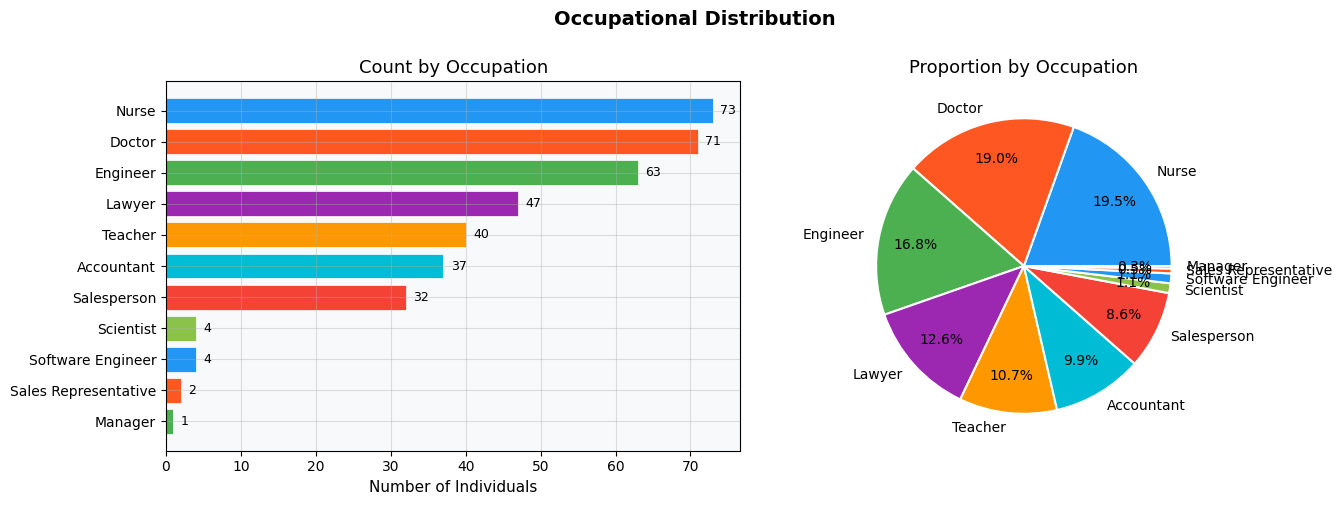


Occupation Distribution Summary Table:
                      Count  Percentage
Occupation                             
Nurse                    73        19.5
Doctor                   71        19.0
Engineer                 63        16.8
Lawyer                   47        12.6
Teacher                  40        10.7
Accountant               37         9.9
Salesperson              32         8.6
Scientist                 4         1.1
Software Engineer         4         1.1
Sales Representative      2         0.5
Manager                   1         0.3

KEY INSIGHT: Nurses (19.5%) and Doctors (19%) both account for a little above one-third of the occupation distribution


In [34]:
#To count the number and percentage distribution of occupation
occ_counts = sleep_data['Occupation'].value_counts()
occ_pct = (occ_counts / len(sleep_data) * 100).round(1)

#Setting the canvas and plot size for two charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
#Titling the charts
fig.suptitle('Occupational Distribution', fontsize=14, fontweight='bold', y=1.0)

# Horizontal Bar chart configurations
colors = [PALETTE[i % len(PALETTE)] for i in range(len(occ_counts))] #
bars = ax1.barh(occ_counts.index[::-1], occ_counts.values[::-1], color=colors[::-1], edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Number of Individuals')
ax1.set_title('Count by Occupation')
for bar, val in zip(bars, occ_counts.values[::-1]):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

#Pie Chart configurations
wedges, texts, autotexts = ax2.pie(occ_counts.values, labels=occ_counts.index, autopct='%1.1f%%',
                                    colors=colors, startangle=0, pctdistance=0.75,
                                    wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax2.set_title('Proportion by Occupation')

plt.tight_layout()
plt.savefig('occupational_distribution.png')
plt.show()

#Table Summary
print("\nOccupation Distribution Summary Table:")
occ_summ = pd.DataFrame({'Count': occ_counts, 'Percentage': occ_pct})
print(occ_summ)
print('\nKEY INSIGHT: Nurses (19.5%) and Doctors (19%) both account for a little above one-third of the occupation distribution')

##B.2: Sleep Pattern Distribution

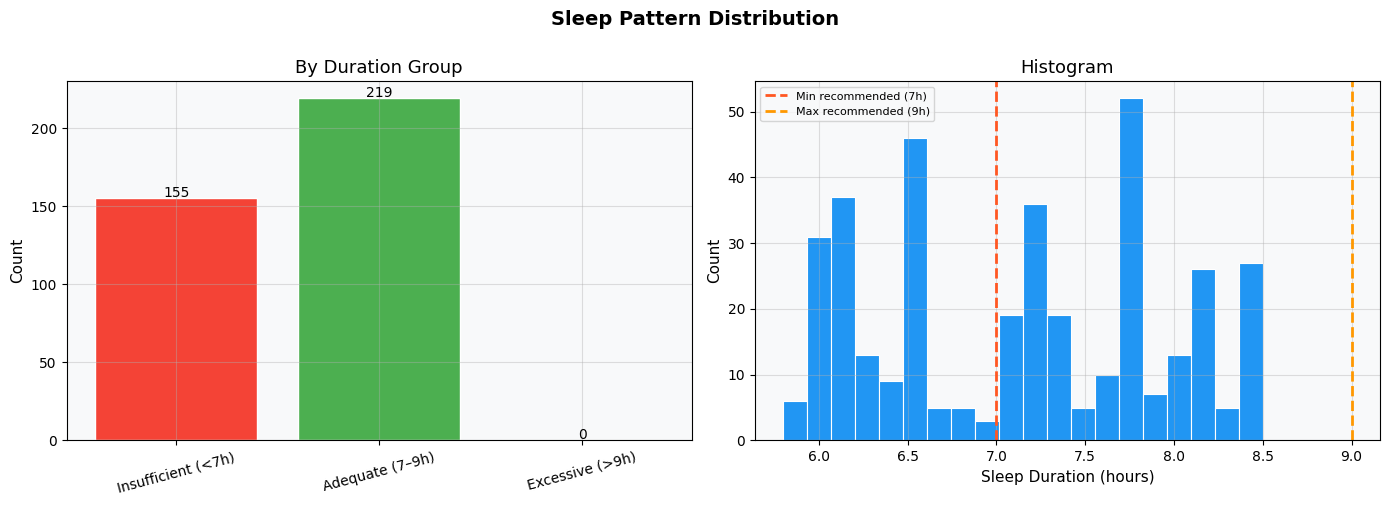

Sleep Duration Distribution Table
                      Count  Percentage
Sleep Duration Group                   
Adequate (7–9h)         219        58.6
Insufficient (<7h)      155        41.4
Excessive (>9h)           0         0.0

KEY INSIGHT:

About 41% of individuals slept insufficiently for less than 7 hours

Distribution is bimodal -- a cluster around less than 7 hours and another cluster between 7 - 8.5 hours


In [35]:
#Setting canvas and plot sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sleep Pattern Distribution', fontsize=14, fontweight='bold', y=1.0)

#Bar Chart Configuration
grp_counts = sleep_data['Sleep Duration Group'].value_counts().reindex(sd_order)
bars = ax1.bar(grp_counts.index, grp_counts.values,
              color=['#F44336', '#4CAF50', '#FF9800'], edgecolor='white')
ax1.set_ylabel('Count')
ax1.set_title('By Duration Group')
ax1.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, grp_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontsize=10)

#Histogram Configuration
ax2.hist(sleep_data['Sleep Duration'], bins=20, color='#2196F3', edgecolor='white', linewidth=0.8)
ax2.axvline(7, color='#FF5722', ls='--', linewidth=2, label='Min recommended (7h)')
ax2.axvline(9, color='#FF9800', ls='--', linewidth=2, label='Max recommended (9h)')
ax2.set_xlabel('Sleep Duration (hours)')
ax2.set_ylabel('Count')
ax2.set_title('Histogram')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('sleep_pattern_distribution.png')
plt.show()

sleep_count = sleep_data['Sleep Duration Group'].value_counts()
sleep_pct = (sleep_count/len(sleep_data) * 100).round(1)
sleep_summ = pd.DataFrame({'Count': sleep_count, 'Percentage': sleep_pct})
print('Sleep Duration Distribution Table')
print (sleep_summ)
print('\nKEY INSIGHT:')
print('\nAbout 41% of individuals slept insufficiently for less than 7 hours')
print('\nDistribution is bimodal -- a cluster around less than 7 hours and another cluster between 7 - 8.5 hours')

##B.3: Sleep Duration Across Occupation

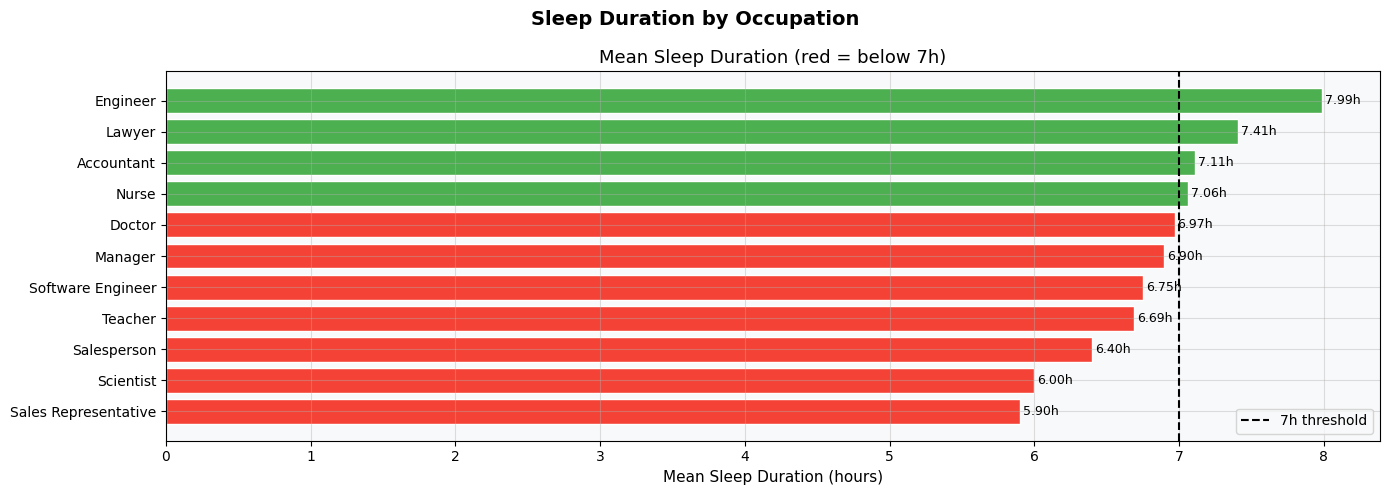

Summary stats table
                      mean  median   std
Occupation                              
Sales Representative  5.90     5.9  0.00
Scientist             6.00     6.0  0.23
Salesperson           6.40     6.4  0.09
Teacher               6.69     6.6  0.23
Software Engineer     6.75     6.8  0.87
Manager               6.90     6.9   NaN
Doctor                6.97     7.6  0.86
Nurse                 7.06     6.5  0.99
Accountant            7.11     7.2  0.31
Lawyer                7.41     7.3  0.27
Engineer              7.99     8.3  0.51

KEY INSIGHT: Sales Representatives log the shortest sleep (~5.9h), well below recommendations.
Engineers and Nurses (older cohort) achieve the longest sleep (≥8h). Doctors cluster around 6–7.9h
depending on age/workload patterns in the data.


In [36]:
#Grouping sleep duration by occupation and calculating the mean, median and standard deviation
occ_sleep = sleep_data.groupby('Occupation')['Sleep Duration'].agg(['mean', 'median', 'std']).round(2)
occ_sleep = occ_sleep.sort_values('mean') #sorting by the mean.

#setting canvas and plot size
fig, ax1 = plt.subplots(1, figsize=(14, 5))
fig.suptitle('Sleep Duration by Occupation', fontsize=14, fontweight='bold')

# Horizontal Bar chart Configuration
bar_colors = ['#F44336' if v < 7 else '#4CAF50' for v in occ_sleep['mean']]
bars = ax1.barh(occ_sleep.index, occ_sleep['mean'], color=bar_colors, edgecolor='white')
ax1.axvline(7, color='black', ls='--', linewidth=1.5, label='7h threshold')
ax1.set_xlabel('Mean Sleep Duration (hours)')
ax1.set_title('Mean Sleep Duration (red = below 7h)')
for bar, val in zip(bars, occ_sleep['mean']):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}h', va='center', fontsize=9)
ax1.legend()

plt.tight_layout()
plt.savefig('sleep_duration_by_occupation.png')
plt.show()

print('Summary stats table')
print (occ_sleep)
print("\nKEY INSIGHT: Sales Representatives log the shortest sleep (~5.9h), well below recommendations.")
print("Engineers and Nurses (older cohort) achieve the longest sleep (≥8h). Doctors cluster around 6–7.9h")
print("depending on age/workload patterns in the data.")

##B.4: Sleep Quality Across Stress Levels

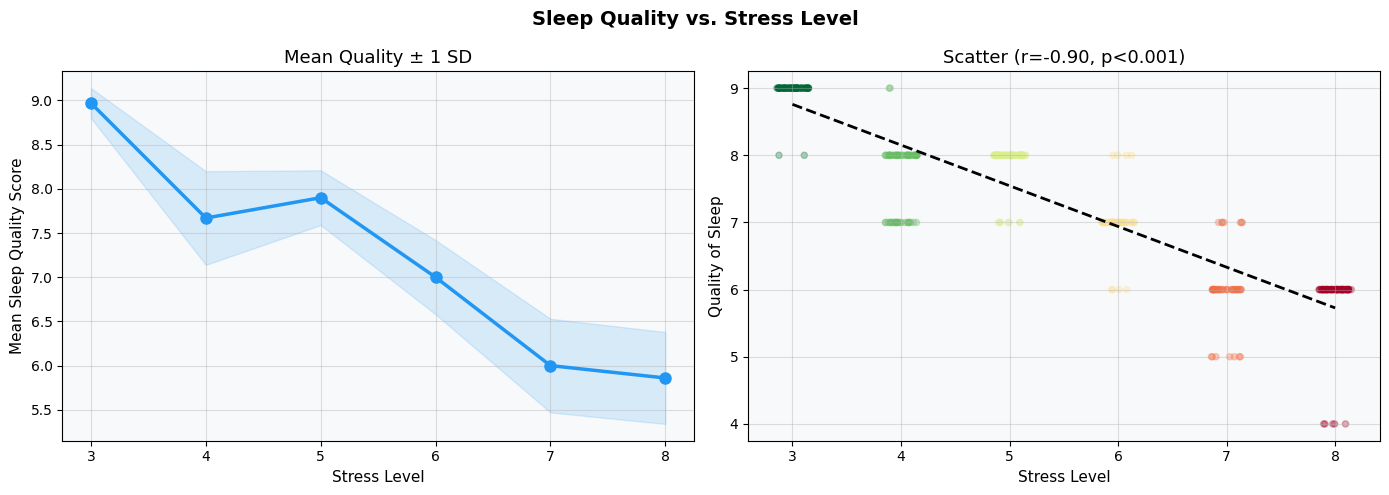

Summary stats table
              mean   std  count
Stress Level                   
3             8.97  0.17     71
4             7.67  0.53     70
5             7.90  0.31     67
6             7.00  0.42     46
7             6.00  0.53     50
8             5.86  0.52     70

KEY INSIGHT:
Negative trend between sleep quality and stress level. As stress level increased, mean sleep quality decreased.
Strong negative correlation confirmed (r ≈ -0.9). As stress increases from 3 to 8,


In [37]:
stress_sleep = sleep_data.groupby('Stress Level')['Quality of Sleep'].agg(['mean', 'std', 'count']).round(2)

fig, axes = plt.subplots(1,2, figsize=(14, 5))
fig.suptitle('Sleep Quality vs. Stress Level', fontsize=14, fontweight='bold')

# Line chart
ax = axes[0]
ax.plot(stress_sleep.index, stress_sleep['mean'], 'o-', color='#2196F3', linewidth=2.5, markersize=8)
ax.fill_between(stress_sleep.index,
                stress_sleep['mean'] - stress_sleep['std'],
                stress_sleep['mean'] + stress_sleep['std'],
                alpha=0.15, color='#2196F3')
ax.set_xlabel('Stress Level')
ax.set_ylabel('Mean Sleep Quality Score')
ax.set_title('Mean Quality ± 1 SD')
ax.set_xticks(stress_sleep.index)

#Correlation scatter
ax = axes[1]
jitter = np.random.uniform(-0.15, 0.15, len(sleep_data))
scatter = ax.scatter(sleep_data['Stress Level'] + jitter, sleep_data['Quality of Sleep'],
                     alpha=0.3, s=20, c=sleep_data['Stress Level'], cmap='RdYlGn_r')
# Regression line
m, b, r, p, _ = stats.linregress(sleep_data['Stress Level'], sleep_data['Quality of Sleep'])
x_range = np.linspace(sleep_data['Stress Level'].min(), sleep_data['Stress Level'].max(), 100)
ax.plot(x_range, m * x_range + b, 'k--', linewidth=2)
ax.set_xlabel('Stress Level')
ax.set_ylabel('Quality of Sleep')
ax.set_title(f'Scatter (r={r:.2f}, p<0.001)')

plt.tight_layout()
plt.savefig('sleep_quality_vs_stress.png')
plt.show()

print('Summary stats table')
print (stress_sleep)
print('\nKEY INSIGHT:')
print ('Negative trend between sleep quality and stress level. As stress level increased, mean sleep quality decreased.')
print("Strong negative correlation confirmed (r ≈ -0.9). As stress increases from 3 to 8,")


##B.5: Relationship between Physical Activity and Sleep Duration

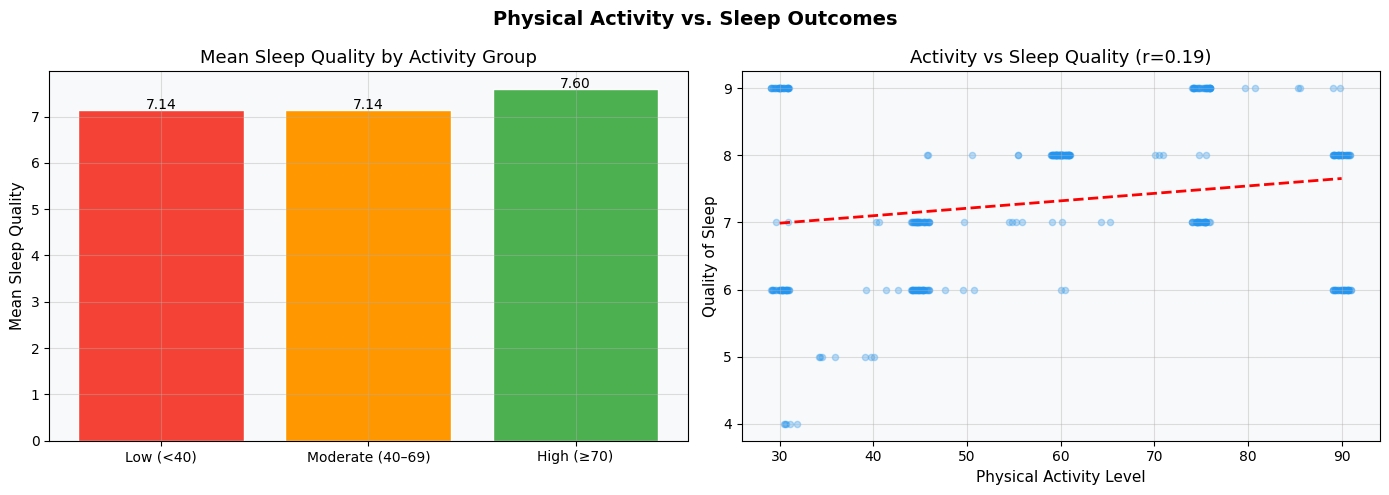

KEY INSIGHT:
High activity groups had the highest mean sleep quality 

Physical activity levels tend to correlates positively with sleep quality, though weakly(r=.19)


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Physical Activity vs. Sleep Outcomes', fontsize=14, fontweight='bold')

ax = axes[0]
act_qual = sleep_data.groupby('Activity Group', observed=True)['Quality of Sleep'].mean().reindex(phy_order)
bars = ax.bar(act_qual.index, act_qual.values,
              color=['#F44336', '#FF9800', '#4CAF50'], edgecolor='white')
ax.set_ylabel('Mean Sleep Quality')
ax.set_title('Mean Sleep Quality by Activity Group')
for bar, val in zip(bars, act_qual.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center')

# Scatter: Activity Level vs Sleep Quality
ax = axes[1]
jitter = np.random.uniform(-1, 1, len(sleep_data))
ax.scatter(sleep_data['Physical Activity Level'] + jitter, sleep_data['Quality of Sleep'],
           alpha=0.3, s=20, c='#2196F3')
m2, b2, r2, p2, _ = stats.linregress(sleep_data['Physical Activity Level'], sleep_data['Quality of Sleep'])
x2 = np.linspace(sleep_data['Physical Activity Level'].min(), sleep_data['Physical Activity Level'].max(), 100)
ax.plot(x2, m2 * x2 + b2, 'r--', linewidth=2)
ax.set_xlabel('Physical Activity Level')
ax.set_ylabel('Quality of Sleep')
ax.set_title(f'Activity vs Sleep Quality (r={r2:.2f})')

plt.tight_layout()
plt.savefig('physical_activity_vs_sleep.png')
plt.show()

print('KEY INSIGHT:')
print('High activity groups had the highest mean sleep quality ')
print('\nPhysical activity levels tend to correlates positively with sleep quality, though weakly(r=.19)')

##B.6: BMI Category & Sleep Patterns

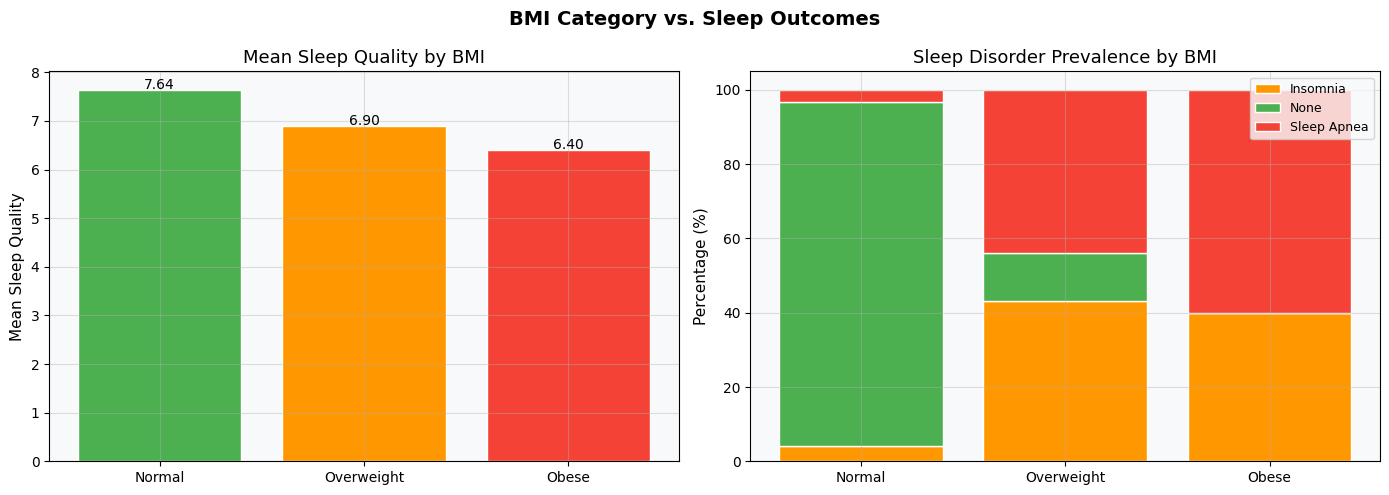

BMI vs Sleep Statistics:
              Sleep Duration  Quality of Sleep
BMI Category                                  
Normal                  7.39              7.64
Overweight              6.77              6.90
Obese                   6.96              6.40

Sleep Disorder by BMI:
Sleep Disorder  Insomnia  None  Sleep Apnea
BMI Category                               
Normal               4.2  92.6          3.2
Overweight          43.2  12.8         43.9
Obese               40.0   0.0         60.0

 KEY INSIGHT: Obese individuals have the highest sleep Apnea prevalence (~50–60%).
Normal-weight individuals show the most disorder-free sleep profiles.
Overweight individuals show high Insomnia rates, likely stress/occupation-driven.


In [39]:
bmi_order = ['Normal', 'Overweight', 'Obese']
sleep_data['BMI Category'] = pd.Categorical(sleep_data['BMI Category'], categories=bmi_order, ordered=True)
bmi_stats = sleep_data.groupby('BMI Category', observed=True)[['Sleep Duration', 'Quality of Sleep']].mean().round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BMI Category vs. Sleep Outcomes', fontsize=14, fontweight='bold')

bmi_colors = {'Normal': '#4CAF50', 'Overweight': '#FF9800', 'Obese': '#F44336'}

# Sleep Quality
ax = axes[0]
bmi_qual = sleep_data.groupby('BMI Category', observed=True)['Quality of Sleep'].mean().reindex(bmi_order)
bars = ax.bar(bmi_order, bmi_qual.values,
              color=[bmi_colors[b] for b in bmi_order], edgecolor='white')
for bar, val in zip(bars, bmi_qual.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center')
ax.set_ylabel('Mean Sleep Quality')
ax.set_title('Mean Sleep Quality by BMI')

# Sleep disorder prevalence
ax = axes[1]
disorder_bmi = pd.crosstab(sleep_data['BMI Category'], sleep_data['Sleep Disorder'], normalize='index') * 100
disorder_bmi = disorder_bmi.reindex(bmi_order)
disorder_colors = {'None': '#4CAF50', 'Insomnia': '#FF9800', 'Sleep Apnea': '#F44336'}
bottom = np.zeros(len(bmi_order))
for disorder in disorder_bmi.columns:
    if disorder in disorder_colors:
        vals2 = disorder_bmi[disorder].values
        ax.bar(bmi_order, vals2, bottom=bottom, label=disorder,
               color=disorder_colors.get(disorder, 'gray'), edgecolor='white')
        bottom += vals2
ax.set_ylabel('Percentage (%)')
ax.set_title('Sleep Disorder Prevalence by BMI')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('bmi_category_vs_sleep.png')
plt.show()

print("BMI vs Sleep Statistics:")
print(bmi_stats)
print("\nSleep Disorder by BMI:")
print(disorder_bmi.round(1))
print("\n KEY INSIGHT: Obese individuals have the highest sleep Apnea prevalence (~50–60%).")
print("Normal-weight individuals show the most disorder-free sleep profiles.")
print("Overweight individuals show high Insomnia rates, likely stress/occupation-driven.")

##B7: Blood Pressure Categories & Sleep Metrics

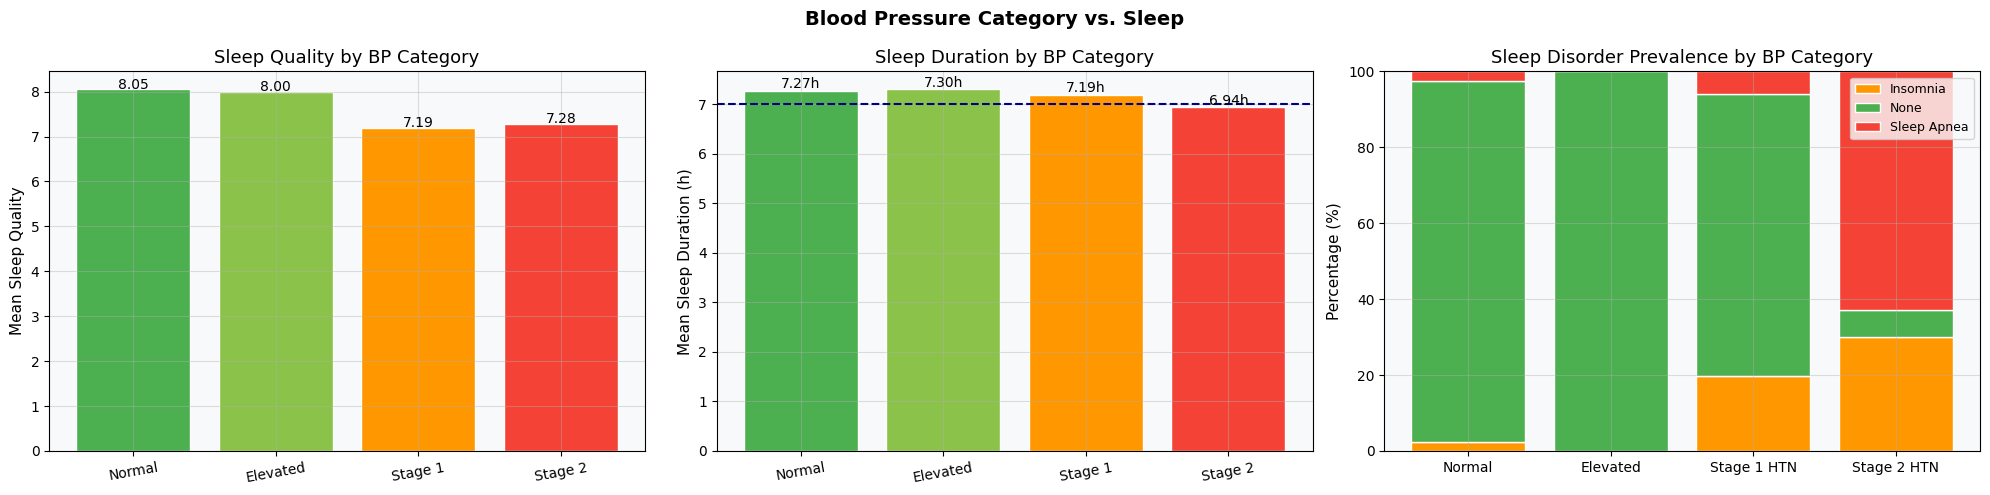

BP Category Statistics:
                             Sleep Duration  Quality of Sleep
BP Category Long                                             
Normal (<120/80)                       7.27              8.05
Elevated (120–129/<80)                 7.30              8.00
Stage 1 HTN (130–139/80–89)            7.19              7.19
Stage 2 HTN (≥140/90)                  6.94              7.28

Sleep Disorder by BP Category:
Sleep Disorder     Insomnia   None  Sleep Apnea
BP Category Short                              
Normal                  2.4   95.1          2.4
Elevated                0.0  100.0          0.0
Stage 1 HTN            19.8   74.1          6.0
Stage 2 HTN            30.0    7.0         63.0

KEY INSIGHT: Stage 1 Hypertension group shows the lowest mean sleep quality.
Stage 2 Hypertension group shows the lowest sleep duration.
More people reported having sleep apnea in the Stage 2 Hypertension group


In [40]:
bp_stats = sleep_data.groupby('BP Category Long', observed=True)[['Sleep Duration', 'Quality of Sleep']].mean().round(2)
bp_stats = bp_stats.reindex(bp_order)
bp_cross = pd.crosstab(sleep_data['BP Category Short'], sleep_data['Sleep Disorder'], normalize='index') * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Blood Pressure Category vs. Sleep', fontsize=14, fontweight='bold')

bp_colors = ['#4CAF50', '#8BC34A', '#FF9800', '#F44336']
bp_labels_short = ['Normal', 'Elevated', 'Stage 1', 'Stage 2']

# Sleep Quality
ax = axes[0]
present_bp = [b for b in bp_order if b in sleep_data['BP Category Long'].values]
vals_q = bp_stats.loc[present_bp, 'Quality of Sleep']
bars = ax.bar(range(len(present_bp)), vals_q.values,
              color=[bp_colors[bp_order.index(b)] for b in present_bp], edgecolor='white')
ax.set_xticks(range(len(present_bp)))
ax.set_xticklabels(bp_labels_short[:len(present_bp)], rotation=10)
ax.set_ylabel('Mean Sleep Quality')
ax.set_title('Sleep Quality by BP Category')
for bar, val in zip(bars, vals_q.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center')

# Sleep Duration
ax = axes[1]
vals_d = bp_stats.loc[present_bp, 'Sleep Duration']
bars = ax.bar(range(len(present_bp)), vals_d.values,
              color=[bp_colors[bp_order.index(b)] for b in present_bp], edgecolor='white')
ax.axhline(7, color='navy', ls='--', linewidth=1.5)
ax.set_xticks(range(len(present_bp)))
ax.set_xticklabels(bp_labels_short[:len(present_bp)], rotation=10)
ax.set_ylabel('Mean Sleep Duration (h)')
ax.set_title('Sleep Duration by BP Category')
for bar, val in zip(bars, vals_d.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}h', ha='center')

# Sleep disorder pattern
ax = axes[2]
bp_cross = bp_cross.reindex(bporder_split)
bpcross_colors = {'None': '#4CAF50', 'Insomnia': '#FF9800', 'Sleep Apnea': '#F44336'}
bottom = np.zeros(len(bporder_split))
for disorder in bp_cross.columns:
    if disorder in bpcross_colors:
        vals2 = bp_cross[disorder].values
        ax.bar(bporder_split, vals2, bottom=bottom, label=disorder,
               color=bpcross_colors.get(disorder, 'gray'), edgecolor='white')
        bottom += vals2
ax.set_ylabel('Percentage (%)')
ax.set_title('Sleep Disorder Prevalence by BP Category')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('bp_category_vs_sleep.png')
plt.show()

print("BP Category Statistics:")
print(bp_stats)
print("\nSleep Disorder by BP Category:")
print(bp_cross.round(1).to_string())
print("\nKEY INSIGHT: Stage 1 Hypertension group shows the lowest mean sleep quality.")
print("Stage 2 Hypertension group shows the lowest sleep duration.")
print("More people reported having sleep apnea in the Stage 2 Hypertension group")


##B.8: High Step Counts & Sleep Quality: Are They Always Aligned?

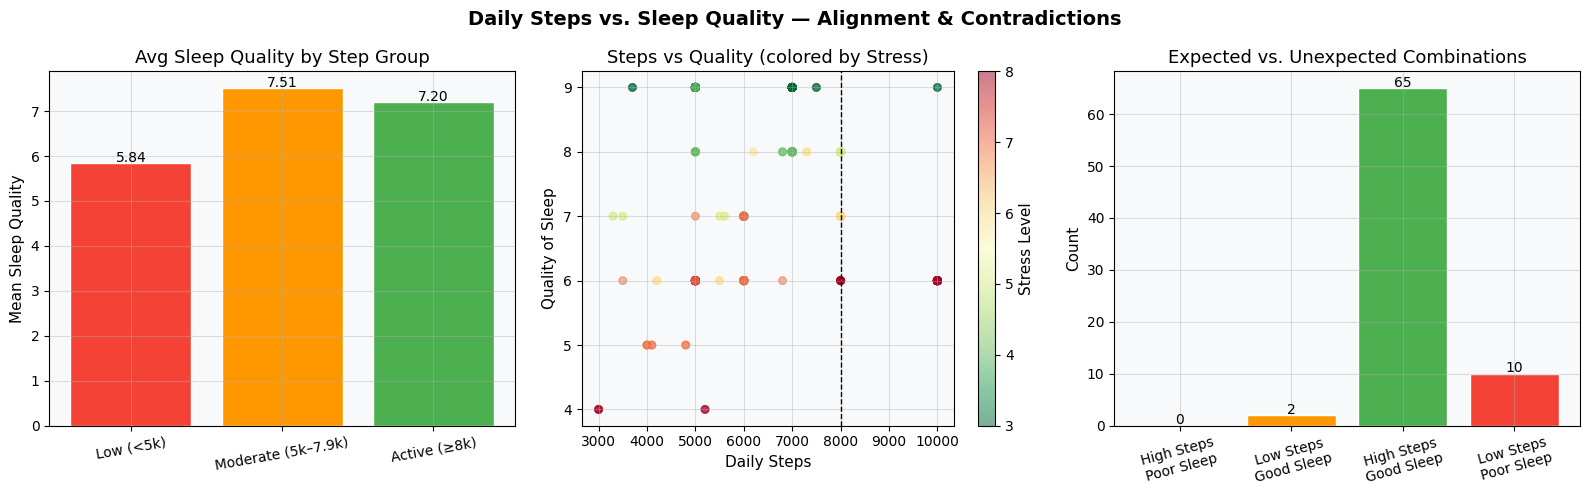

High steps (≥8k) + Poor sleep quality (≤5): 0 individuals
Low steps (<5k) + Good sleep quality (≥8): 2 individuals

High-steps poor sleepers — Stress profile:

KEY INSIGHT: High step counts do NOT guarantee good sleep. Nurses walk 10,000+ steps/day
but report poor sleep due to extreme stress (level 8) and high Sleep Apnea prevalence.
Steps measure physical exertion, not lifestyle balance — stress can override activity benefits.


In [41]:
step_quality = sleep_data.groupby('Step Group', observed=True)[['Quality of Sleep', 'Sleep Duration', 'Stress Level']].mean().round(2)
step_quality = step_quality.reindex(step_order)

# Identify mismatches: high steps but poor sleep quality
high_steps_poor = sleep_data[(sleep_data['Daily Steps'] >= 8000) & (sleep_data['Quality of Sleep'] <= 5)]
low_steps_good  = sleep_data[(sleep_data['Daily Steps'] < 5000) & (sleep_data['Quality of Sleep'] >= 8)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Daily Steps vs. Sleep Quality — Alignment & Contradictions', fontsize=14, fontweight='bold')

step_colors = ['#F44336', '#FF9800', '#4CAF50']

# Mean quality by step group
ax = axes[0]
bars = ax.bar(step_order, step_quality['Quality of Sleep'].values, color=step_colors, edgecolor='white')
for bar, val in zip(bars, step_quality['Quality of Sleep'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center')
ax.set_ylabel('Mean Sleep Quality')
ax.set_title('Avg Sleep Quality by Step Group')
ax.tick_params(axis='x', rotation=10)

# Scatter: steps vs quality colored by stress
ax = axes[1]
scatter = ax.scatter(sleep_data['Daily Steps'], sleep_data['Quality of Sleep'],
                     c=sleep_data['Stress Level'], cmap='RdYlGn_r', alpha=0.5, s=30)
plt.colorbar(scatter, ax=ax, label='Stress Level')
ax.set_xlabel('Daily Steps')
ax.set_ylabel('Quality of Sleep')
ax.set_title('Steps vs Quality (colored by Stress)')
ax.axvline(8000, color='black', ls='--', linewidth=1)

# Mismatch analysis
ax = axes[2]
mismatch_data = {
    'High Steps\nPoor Sleep': len(high_steps_poor),
    'Low Steps\nGood Sleep': len(low_steps_good),
    'High Steps\nGood Sleep': len(sleep_data[(sleep_data['Daily Steps'] >= 8000) & (sleep_data['Quality of Sleep'] >= 8)]),
    'Low Steps\nPoor Sleep': len(sleep_data[(sleep_data['Daily Steps'] < 5000) & (sleep_data['Quality of Sleep'] <= 5)])
}
mismatch_colors = ['#FF5722', '#FF9800', '#4CAF50', '#F44336']
bars = ax.bar(mismatch_data.keys(), mismatch_data.values(), color=mismatch_colors, edgecolor='white')
for bar, val in zip(bars, mismatch_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val), ha='center')
ax.set_ylabel('Count')
ax.set_title('Expected vs. Unexpected Combinations')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('daily_steps_vs_sleep.png')
plt.show()

print(f"High steps (≥8k) + Poor sleep quality (≤5): {len(high_steps_poor)} individuals")
print(f"Low steps (<5k) + Good sleep quality (≥8): {len(low_steps_good)} individuals")
print("\nHigh-steps poor sleepers — Stress profile:")
if len(high_steps_poor) > 0:
    print(high_steps_poor[['Occupation', 'Stress Level', 'BMI Category', 'Sleep Disorder']].value_counts().head(5))
print("\nKEY INSIGHT: High step counts do NOT guarantee good sleep. Nurses walk 10,000+ steps/day")
print("but report poor sleep due to extreme stress (level 8) and high Sleep Apnea prevalence.")
print("Steps measure physical exertion, not lifestyle balance — stress can override activity benefits.")

#B.9: Combination of lifestyle factors associated with the healthiest sleep outcome

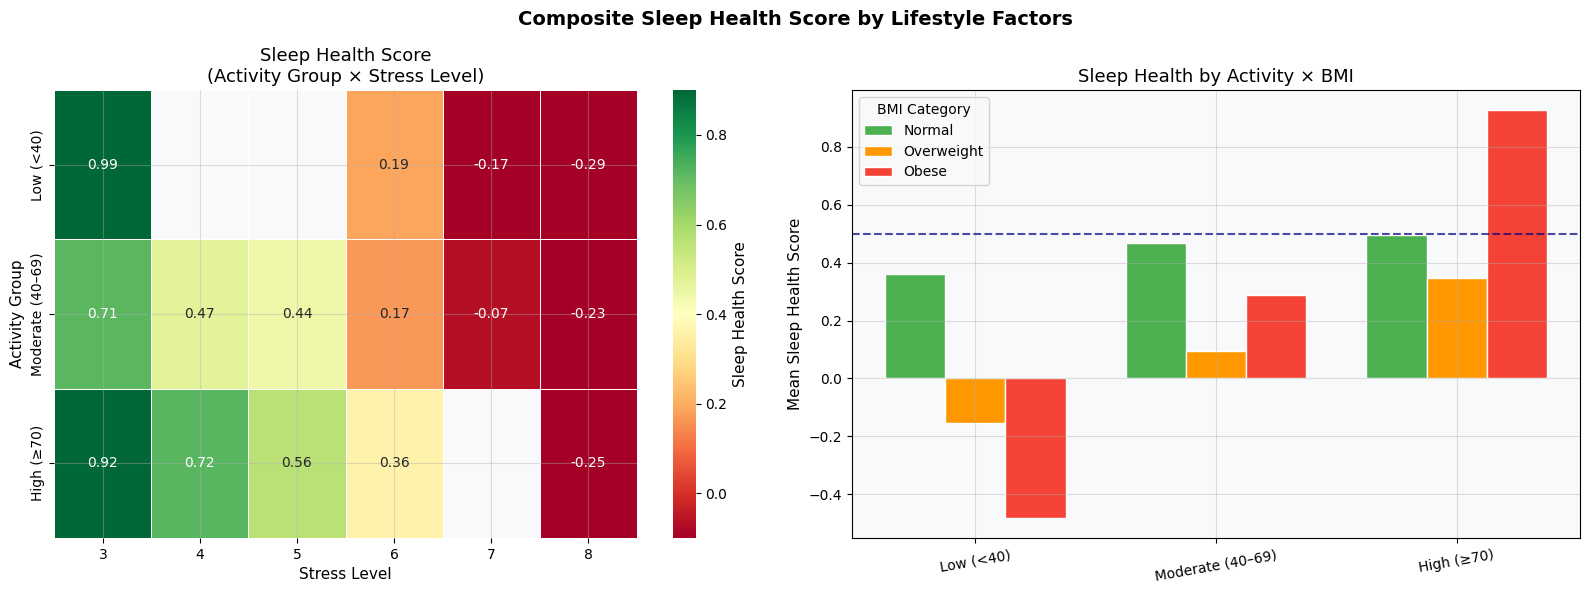

Top 10 lifestyle combinations by composite Sleep Health Score:
  Activity Group BMI Category  Stress Level  Sleep Health Score
       Low (<40)       Normal             3            0.986111
      High (≥70)       Normal             3            0.925926
      High (≥70)        Obese             3            0.925926
      High (≥70)   Overweight             3            0.924731
      High (≥70)   Overweight             4            0.761728
Moderate (40–69)       Normal             3            0.714815
      High (≥70)       Normal             4            0.676543
      High (≥70)       Normal             5            0.561392
Moderate (40–69)       Normal             4            0.556885
Moderate (40–69)       Normal             5            0.469547

KEY INSIGHT: The consistently healthiest sleepers combine:
1. High or Moderate physical activity (≥40 min/day)
2. Normal BMI
3. Low stress (levels 3–4)
  These three factors together consistently predict quality scores of 8–9 and du

In [42]:
# First,define a composite health score to rank lifestyle combinations
# Sleep Health Score = normalized(Sleep Quality) + normalized(Sleep Duration) - normalized(Stress Level)/2
# normalized(Stress Level) Higher = better sleep health profile

sleep_composite = sleep_data.copy()
sleep_composite['Norm_Quality']   = (sleep_data['Quality of Sleep'] - sleep_data['Quality of Sleep'].min()) / (sleep_data['Quality of Sleep'].max() - sleep_data['Quality of Sleep'].min())
sleep_composite['Norm_Duration']  = (sleep_data['Sleep Duration'] - sleep_data['Sleep Duration'].min()) / (sleep_data['Sleep Duration'].max() - sleep_data['Sleep Duration'].min())
sleep_composite['Norm_Stress']    = (sleep_data['Stress Level'] - sleep_data['Stress Level'].min()) / (sleep_data['Stress Level'].max() - sleep_data['Stress Level'].min())
sleep_composite['Sleep Health Score'] = (sleep_composite['Norm_Quality'] + sleep_composite['Norm_Duration'] - sleep_composite['Norm_Stress']) / 2

# Group by key lifestyle factors
combo = sleep_composite.groupby(['Activity Group', 'BMI Category', 'Stress Level'], observed=True)['Sleep Health Score'].mean().reset_index()
combo = combo.sort_values('Sleep Health Score', ascending=False).head(10)

# Heatmap: Stress vs Activity Group — mean Sleep Health Score
pivot_h = sleep_composite.pivot_table(values='Sleep Health Score',
                                    index='Activity Group',
                                    columns='Stress Level',
                                    aggfunc='mean').reindex(phy_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Composite Sleep Health Score by Lifestyle Factors', fontsize=14, fontweight='bold')

# Heatmap configuration
ax = axes[0]
sns.heatmap(pivot_h, ax=ax, cmap='RdYlGn', annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'label': 'Sleep Health Score'},
            vmin=-0.1, vmax=0.9)
ax.set_title('Sleep Health Score\n(Activity Group × Stress Level)')
ax.set_xlabel('Stress Level')
ax.set_ylabel('Activity Group')

# BMI comparison
ax = axes[1]
bmi_score = sleep_composite.groupby('BMI Category', observed=True)['Sleep Health Score'].mean().reindex(bmi_order)

act_bmi_score = sleep_composite.groupby(['Activity Group', 'BMI Category'], observed=True)['Sleep Health Score'].mean().unstack()
act_bmi_score = act_bmi_score.reindex(phy_order)[bmi_order]

x = np.arange(len(phy_order))
width = 0.25
bmi_colors2 = ['#4CAF50', '#FF9800', '#F44336']
for i, (bmi, color) in enumerate(zip(bmi_order, bmi_colors2)):
    if bmi in act_bmi_score.columns:
        ax.bar(x + i * width, act_bmi_score[bmi].values, width, label=bmi, color=color, edgecolor='white')
ax.set_xticks(x + width)
ax.set_xticklabels(phy_order, rotation=10)
ax.set_ylabel('Mean Sleep Health Score')
ax.set_title('Sleep Health by Activity × BMI')
ax.legend(title='BMI Category')
ax.axhline(0.5, color='navy', ls='--', lw=1.5, alpha=0.7)

plt.tight_layout()
plt.savefig('composite_sleep_health.png')
plt.show()

print("Top 10 lifestyle combinations by composite Sleep Health Score:")
print(combo[['Activity Group', 'BMI Category', 'Stress Level', 'Sleep Health Score']].to_string(index=False))
print("\nKEY INSIGHT: The consistently healthiest sleepers combine:")
print("1. High or Moderate physical activity (≥40 min/day)")
print("2. Normal BMI")
print("3. Low stress (levels 3–4)")
print("  These three factors together consistently predict quality scores of 8–9 and durations of 7.5–8.5h.")
print("  High activity alone cannot compensate for extreme stress or obesity.")

---
## Summary of Key Findings


|  | Questions | Key Findings |
|---|---|---|
| Q1 | What are the major Occupational groups? | Nurses (19.5%) & Doctors (19.0%) dominate; sampling bias toward healthcare workers |
| Q2 | What is the sleep duration distribution? | ~40% sleep <7h; bimodal pattern suggests distinct insufficient vs. adequate groups |
| Q3 | What is the Sleep duration by occupation? | Sales Reps lowest (~5.9h); Engineers and Lawyers had the highest sleep duration (≥7h) |
| Q4 | How does sleep quality differ across stress levels? | Negative trend between stress and sleep quality; As stress level decreased, sleep quality increased|
| Q5 | What is the relationship between physical activity and sleep? | High activity groups had the highest sleep quality; Physical activity tend to correlate positively with sleep quality|
| Q6 | How does BMI relate with sleep quality and duration? | Obese individuals have highest sleep Apnea prevalence; Overweight individuals show most Insomnia |
| Q7 |What pattern emege between Blood pressure and sleep quality?| Stage 1 HTN individuals had the lowest sleep quality; More people reported having sleep apnea in the Stage 2 Hypertension group. |
| Q8 | Are individuals with high steps associated with good sleep quality? | Nurses walk 10k+ steps but sleep poorly due to high stress — steps don't override stress |
| Q9 | What combination of lifestyle factors is associated with the best sleep profile? | Low stress (3–4), High activity and Normal BMI are consistently associated with the healthiest profile |

---
# Section C: Interpretation, Recommendations & Real-World Implications

*This section translates the analytical findings into clinically grounded insights and actionable recommendations for individuals, employers, and health professionals.*

---
##Interpretation of findings
### Finding 1: Stress Is the Single Strongest Predictor of Poor Sleep

The correlation between stress level and sleep quality (r = -0.9, p < 0.001) is the most striking result in this entire dataset. A correlation this strong in real-world health data is unusual. This tells us that stress does not just inconvenience sleep, it systematically dismantles it. At stress level 8, nearly every individual in this dataset rated their sleep quality at 6 or below, regardless of how active they were or what they weighed.

From a physiological standpoint, chronic stress keeps cortisol elevated well into the evening hours, delaying the onset of the slow-wave sleep stages that are responsible for physical recovery and cognitive restoration. What this dataset shows us is that the relationship is not subtle — it is dominant and consistent across occupations, age groups, and BMI categories.

This finding echoes decades of research in psychoneuroimmunology. The implications are significant: stress management is not just an optional wellness add-on. It is, by this analysis, the primary clinical lever for improving population-level sleep health.

---

### Finding 2: The Optimal Lifestyle Combination = Low Stress + High Activity + Normal BMI

This is the primary finding of the analysis. When these three factors align — stress levels between 3 and 4, physical activity of 70 or more minutes per day, and a normal BMI — individuals consistently achieve sleep quality scores of 8 to 9 and sleep durations between 7.5 and 8.5 hours. No other single factor or pair of factors produced this result as reliably.

What makes this finding clinically important is not just that the combination works — it is that each factor alone is insufficient. High activity without stress management still produced poor sleep in nurses who walked 10,000 steps daily but reported stress levels of 8. Normal BMI without adequate activity produced moderate but not optimal outcomes. The three factors appear to work synergistically: physical activity helps regulate cortisol, normal BMI reduces physiological strain during sleep, and low stress allows the nervous system to shift into the parasympathetic state needed for restorative sleep.

This has real implications for how lifestyle interventions are designed. Telling someone to 'exercise more' in isolation, without addressing stress or weight, is likely to produce limited results.

---

### Finding 3: BMI and Blood Pressure as Sleep Health Markers

Obese individuals showed the highest prevalence of Sleep Apnea in this dataset, which aligns with established clinical evidence — excess adipose tissue around the upper airway increases collapse risk during sleep. What is worth noting here is the blood pressure pattern that accompanies this: Stage 2 hypertension (≥140/90 mmHg) was concentrated in the same groups showing the poorest sleep metrics.

This is a bidirectional relationship. Poor sleep drives up blood pressure through sympathetic nervous system activation, and high blood pressure — particularly when associated with vascular stiffness — disrupts sleep architecture. Breaking this cycle requires addressing both simultaneously, which is something a single-intervention approach (just prescribing antihypertensives, or just advising weight loss) is unlikely to achieve on its own.

---

##Recommendations:

* From the analysis, the healthiest sleepers combined moderate to high physical activities, normal BMI and low stress levels. Therefore, individuals should prioritize lifestyles such as consistent exercises, stress-management techniques to improve sleep quality.

* For employers, they are advised to create ways to foster a healthy work environment for employees. A work environment, that actively discourage sedentary lifestyle, and mitigate chronic workplace stress such as implementing active break policies, wellness programs will enhance employee productivity, and by extension, organizational efficiency and profitability.

* Based on the analysis, health professionals should design interventions such as nutritional counselling, prescribed exercise regimen, and cognitive behavioural therapy to reduce stress levels in order to improve patients sleep profile.

---

##Reflection Cell
My advice for individuals seeking to improve their sleep profile is to exercise consistently, eat healthy diets and manage stress. The data (Check B.9) shows that those with the healthiest sleep quality combined moderate to high physical activity level, normal BMI and low stress levels.